# Drug-Target Centric Metrics Exploration

This notebook explores drug-target binding affinity and selectivity metrics data.

## Data Overview

The `DrugTargetMetrics` folder contains:

1. **Drug-Centric Metrics** (`drug_selectivity_metrics.csv`):
   - Selectivity scores and entropy measures
   - Binding affinity metrics (aff_n, gap, sr)
   - Number of targets measured
   - Drug names and clinical trial phases

2. **Drug UMAP Clustering** (`drug_umap_clustering.csv`):
   - UMAP dimensionality reduction results
   - Drug type classifications (Highly Selective, Moderate poly-target, Broad-spectrum)
   - Cluster assignments for visualization

3. **Target-Centric Statistics** (`target_binding_stats.csv`):
   - Average selectivity scores per target
   - Binding affinity statistics (Avg_pKd, Max_pKd)
   - Number of drug hits (N_hit)
   - Target Prioritization Index (TPI)
   - Gene information and oncogene roles

4. **Target-Centric Detailed Data** (`target_centric_pan/`):
   - 100 parquet files with detailed per-target drug binding data
   - Likely contains individual drug-target binding affinities

## Key Metrics Explained

- **Selectivity_Score**: Measure of drug selectivity (higher = more selective)
- **pKd**: Negative log of dissociation constant (higher = stronger binding)
- **Entropy**: Measure of binding distribution diversity
- **Gini**: Measure of binding inequality
- **TPI**: Target Prioritization Index
- **N_hit**: Number of drugs binding to target

## 1. Import Libraries

In [1]:
import sys
sys.path.insert(0, '..')
import os
os.chdir('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("Libraries imported successfully!")

Libraries imported successfully!


## 2. Load Drug-Centric Metrics Data

In [ ]:
# Load drug-centric metrics
drug_metrics_file = Path("DrugTargetMetrics/drug_selectivity_metrics.csv")
print(f"Loading drug-centric metrics from {drug_metrics_file}...")
drug_metrics_df = pd.read_csv(drug_metrics_file, low_memory=False)
print(f"Loaded {len(drug_metrics_df):,} records")
print(f"Columns: {len(drug_metrics_df.columns)}")
print(f"\nColumn names:")
print(list(drug_metrics_df.columns))

Loading drug-centric metrics from drug_target_centric_metric/drug_centric_pan_uniprot.csv...
Loaded 14,981 records
Columns: 20

Column names:
['Drug', 'entropy_norm', 'gini_simpson', 'kurtosis', 'aff_n', 'gap', 'sr', 'n_targets_measured', 'entropy_sel', 'gini_sel', 'entropy_sel_n', 'gini_sel_n', 'kurt_n', 'gap_n', 'sr_n', 'Selectivity_Score', 'entropy_rev', 'Drug Chembl ID', 'Drug Name', 'Clinical Trial Phase']


In [3]:
print("=" * 80)
print("DRUG-CENTRIC METRICS OVERVIEW")
print("=" * 80)
print(f"\nShape: {drug_metrics_df.shape}")
print(f"\nFirst few rows:")
display(drug_metrics_df.head(10))

DRUG-CENTRIC METRICS OVERVIEW

Shape: (14981, 20)

First few rows:


,Drug,entropy_norm,gini_simpson,kurtosis,aff_n,gap,sr,n_targets_measured,entropy_sel,gini_sel,entropy_sel_n,gini_sel_n,kurt_n,gap_n,sr_n,Selectivity_Score,entropy_rev,Drug Chembl ID,Drug Name,Clinical Trial Phase
0,CHEMBL1000,0.922746,0.999767,0.530528,0.397263,0.445429,1.058663,20385,0.077254,0.000233,0.134484,0.001786,0.162102,0.407150,0.375980,0.235441,0.077254,CHEMBL1000,Cetirizine,4.0
1,CHEMBL100014,0.967311,0.999897,0.957930,0.135360,0.004691,1.000741,20385,0.032689,0.000103,0.051744,0.000491,0.212693,0.004284,0.004743,0.058501,0.032689,CHEMBL100014,An-9,2.0
2,CHEMBL100109,0.890470,0.999691,0.664990,0.376331,0.078892,1.010084,20385,0.109530,0.000309,0.194407,0.002542,0.178018,0.072109,0.064626,0.153839,0.109530,CHEMBL100109,Chembl100109,NaN
3,CHEMBL100116,0.908725,0.999714,0.923146,0.482391,0.031676,1.003701,20385,0.091275,0.000286,0.160514,0.002314,0.208575,0.028950,0.023713,0.149879,0.091275,CHEMBL100116,Pentazocine,4.0
4,CHEMBL1002,0.911230,0.999747,1.097413,0.272766,0.057814,1.008061,20385,0.088770,0.000253,0.155863,0.001989,0.229203,0.052842,0.051662,0.126627,0.088770,CHEMBL1002,Levosalbutamol,4.0
5,CHEMBL100231,0.953685,0.999818,0.238911,0.465735,0.058739,1.006972,20385,0.046315,0.000182,0.077043,0.001275,0.127584,0.053687,0.044683,0.121129,0.046315,CHEMBL100231,Chembl100231,NaN
6,CHEMBL100239,0.920891,0.999752,1.503657,0.340253,0.041030,1.005380,20385,0.079109,0.000248,0.137927,0.001932,0.277289,0.037500,0.034474,0.131382,0.079109,CHEMBL100239,Tcmdc-131943,NaN
7,CHEMBL100259,0.729001,0.998649,5.526710,0.352921,0.022792,1.002949,20385,0.270999,0.001351,0.494186,0.012934,0.753489,0.020829,0.018899,0.284539,0.270999,CHEMBL100259,Uridine,3.0
8,CHEMBL1003,0.879234,0.999608,2.462038,0.334356,0.015503,1.002036,20385,0.120766,0.000392,0.215266,0.003369,0.390731,0.014167,0.013045,0.158450,0.120766,CHEMBL1003,Clavulanate Potassium,4.0
9,CHEMBL1004,0.915910,0.999765,0.979423,0.230920,0.032463,1.004688,20385,0.084090,0.000235,0.147175,0.001808,0.215237,0.029669,0.030039,0.109523,0.084090,CHEMBL1004,Doxylamine,4.0


In [4]:
print("=" * 80)
print("DRUG-CENTRIC METRICS STATISTICS")
print("=" * 80)

print(f"\nUnique drugs: {drug_metrics_df['Drug'].nunique() if 'Drug' in drug_metrics_df.columns else 'N/A'}")
print(f"Unique ChEMBL IDs: {drug_metrics_df['Drug Chembl ID'].nunique() if 'Drug Chembl ID' in drug_metrics_df.columns else 'N/A'}")
print(f"Unique drug names: {drug_metrics_df['Drug Name'].nunique() if 'Drug Name' in drug_metrics_df.columns else 'N/A'}")

# Key metrics statistics
if 'Selectivity_Score' in drug_metrics_df.columns:
    print(f"\nSelectivity Score statistics:")
    print(drug_metrics_df['Selectivity_Score'].describe())

if 'n_targets_measured' in drug_metrics_df.columns:
    print(f"\nNumber of targets measured statistics:")
    print(drug_metrics_df['n_targets_measured'].describe())

if 'Clinical Trial Phase' in drug_metrics_df.columns:
    phase_counts = drug_metrics_df['Clinical Trial Phase'].value_counts()
    print(f"\nClinical trial phase distribution:")
    print(phase_counts)

DRUG-CENTRIC METRICS STATISTICS

Unique drugs: 14981
Unique ChEMBL IDs: 14981
Unique drug names: 14910

Selectivity Score statistics:
count    14981.000000
mean         0.154837
std          0.051684
min          0.032331
25%          0.117812
50%          0.150019
75%          0.185864
max          0.809570
Name: Selectivity_Score, dtype: float64

Number of targets measured statistics:
count    14981.0
mean     20385.0
std          0.0
min      20385.0
25%      20385.0
50%      20385.0
75%      20385.0
max      20385.0
Name: n_targets_measured, dtype: float64

Clinical trial phase distribution:
Clinical Trial Phase
 4.0    3378
 2.0    2751
 3.0    1067
 1.0     776
-1.0     265
 0.5      14
Name: count, dtype: int64


## 3. Load Drug UMAP Clustering Data

In [ ]:
# Load drug UMAP clustering data
drug_umap_file = Path("DrugTargetMetrics/drug_umap_clustering.csv")
print(f"Loading drug UMAP data from {drug_umap_file}...")
drug_umap_df = pd.read_csv(drug_umap_file, low_memory=False)
print(f"Loaded {len(drug_umap_df):,} records")
print(f"Columns: {len(drug_umap_df.columns)}")
print(f"\nColumn names:")
print(list(drug_umap_df.columns))

Loading drug UMAP data from drug_target_centric_metric/drug_centric_pan_uniprot_umap.csv...
Loaded 14,981 records
Columns: 14

Column names:
['Drug', 'cluster', 'Selectivity_Score', 'entropy_sel_n', 'gini_sel_n', 'kurt_n', 'gap_n', 'sr_n', 'Type', 'x', 'y', 'Drug Chembl ID', 'Drug Name', 'Clinical Trial Phase']


In [6]:
print("=" * 80)
print("DRUG UMAP CLUSTERING OVERVIEW")
print("=" * 80)
print(f"\nShape: {drug_umap_df.shape}")

if 'Type' in drug_umap_df.columns:
    print(f"\nDrug type distribution:")
    print(drug_umap_df['Type'].value_counts())

if 'cluster' in drug_umap_df.columns:
    print(f"\nCluster distribution:")
    print(drug_umap_df['cluster'].value_counts().sort_index())

print(f"\nFirst few rows:")
display(drug_umap_df.head(10))

DRUG UMAP CLUSTERING OVERVIEW

Shape: (14981, 14)

Drug type distribution:
Type
Type III: Broad-spectrum         8082
Type I: Highly Selective         4106
Type II: Moderate poly-target    2793
Name: count, dtype: int64

Cluster distribution:
cluster
0    8082
1    2793
2    4106
Name: count, dtype: int64

First few rows:


,Drug,cluster,Selectivity_Score,entropy_sel_n,gini_sel_n,kurt_n,gap_n,sr_n,Type,x,y,Drug Chembl ID,Drug Name,Clinical Trial Phase
0,CHEMBL1000,1,0.235441,0.134484,0.001786,0.162102,0.407150,0.375980,Type II: Moderate poly-target,-1.583589,0.612076,CHEMBL1000,Cetirizine,4.0
1,CHEMBL100014,0,0.058501,0.051744,0.000491,0.212693,0.004284,0.004743,Type III: Broad-spectrum,14.310394,1.097187,CHEMBL100014,An-9,2.0
2,CHEMBL100109,0,0.153839,0.194407,0.002542,0.178018,0.072109,0.064626,Type III: Broad-spectrum,6.269453,5.130612,CHEMBL100109,Chembl100109,NaN
3,CHEMBL100116,0,0.149879,0.160514,0.002314,0.208575,0.028950,0.023713,Type III: Broad-spectrum,8.618780,4.626670,CHEMBL100116,Pentazocine,4.0
4,CHEMBL1002,0,0.126627,0.155863,0.001989,0.229203,0.052842,0.051662,Type III: Broad-spectrum,8.402534,4.522439,CHEMBL1002,Levosalbutamol,4.0
5,CHEMBL100231,0,0.121129,0.077043,0.001275,0.127584,0.053687,0.044683,Type III: Broad-spectrum,10.615496,0.564681,CHEMBL100231,Chembl100231,NaN
6,CHEMBL100239,0,0.131382,0.137927,0.001932,0.277289,0.037500,0.034474,Type III: Broad-spectrum,8.615932,4.755508,CHEMBL100239,Tcmdc-131943,NaN
7,CHEMBL100259,2,0.284539,0.494186,0.012934,0.753489,0.020829,0.018899,Type I: Highly Selective,1.910377,11.073517,CHEMBL100259,Uridine,3.0
8,CHEMBL1003,2,0.158450,0.215266,0.003369,0.390731,0.014167,0.013045,Type I: Highly Selective,6.430350,8.739769,CHEMBL1003,Clavulanate Potassium,4.0
9,CHEMBL1004,0,0.109523,0.147175,0.001808,0.215237,0.029669,0.030039,Type III: Broad-spectrum,10.458037,4.167463,CHEMBL1004,Doxylamine,4.0


## 4. Load Target-Centric Statistics

In [ ]:
# Load target-centric statistics
target_stats_file = Path("DrugTargetMetrics/target_binding_stats.csv")
print(f"Loading target statistics from {target_stats_file}...")
target_stats_df = pd.read_csv(target_stats_file, low_memory=False)
print(f"Loaded {len(target_stats_df):,} records")
print(f"Columns: {len(target_stats_df.columns)}")
print(f"\nColumn names:")
print(list(target_stats_df.columns))

Loading target statistics from drug_target_centric_metric/target_stats_sorted_onco.csv...
Loaded 1,068 records
Columns: 16

Column names:
['Target', 'Avg_Selectivity_Score', 'Avg_entropy', 'Avg_pKd', 'Max_pKd', 'N_hit', 'TPI', 'Score_LT', 'Entry', 'Entry Name', 'Gene Names', 'Length', 'Sequence', 'EC number', 'Gene', 'Role']


In [8]:
print("=" * 80)
print("TARGET-CENTRIC STATISTICS OVERVIEW")
print("=" * 80)
print(f"\nShape: {target_stats_df.shape}")
print(f"\nFirst few rows:")
display(target_stats_df.head(10))

TARGET-CENTRIC STATISTICS OVERVIEW

Shape: (1068, 16)

First few rows:


,Target,Avg_Selectivity_Score,Avg_entropy,Avg_pKd,Max_pKd,N_hit,TPI,Score_LT,Entry,Entry Name,Gene Names,Length,Sequence,EC number,Gene,Role
0,CCR4_HUMAN,0.471425,0.101836,7.245421,9.554837,14228,0.949736,0.023696,P51679,CCR4_HUMAN,CCR4 CMKBR4,360,MNPTDIADTTLDESIYSNYYLYESIPKPCTKEGIKAFGELFLPPLY...,NaN,CCR4,Oncogene
1,KIT_HUMAN,0.469659,0.101836,7.230410,9.618177,13658,0.911688,0.041477,P10721,KIT_HUMAN,KIT SCFR,976,MRGARGAWDFLCVLLLLLRVQTGSSQPSVSPGEPSPPSIHPGKSDL...,2.7.10.1,KIT,Oncogene
2,CLTR2_HUMAN,0.468701,0.101836,7.213534,9.404004,14212,0.948668,0.024059,Q9NS75,CLTR2_HUMAN,CYSLTR2 CYSLT2 CYSLT2R PSEC0146,346,MERKFMSLQPSISVSEMEPNGTFSNNNSRNCTIENFKREFFPIVYL...,NaN,CYSLTR2,Oncogene
3,CCR7_HUMAN,0.467908,0.101836,7.204928,9.488377,14150,0.944530,0.025955,P32248,CCR7_HUMAN,CCR7 CMKBR7 EBI1 EVI1,378,MDLGKPMKSVLVVALLVIFQVCLCQDEVTDDYIGDNTTVDYTLFES...,NaN,CCR7,Oncogene
4,CXCR4_HUMAN,0.468042,0.101836,7.204446,9.595966,14297,0.954342,0.021370,P61073,CXCR4_HUMAN,CXCR4,352,MEGISIYTSDNYTEEMGSGDYDSMKEPCFREENANFNKIFLPTIYS...,NaN,CXCR4,Oncogene
5,APJ_HUMAN,0.463346,0.101836,7.153969,9.319393,13959,0.931780,0.031609,P35414,APJ_HUMAN,APLNR AGTRL1 APJ,380,MEEGGDFDNYYGADNQSECEYTDWKSSGALIPAIYMLVFLLGTTGN...,NaN,APLNR,Both
6,ACKR3_HUMAN,0.459389,0.101836,7.104656,9.534197,14139,0.943795,0.025820,P25106,ACKR3_HUMAN,ACKR3 CMKOR1 CXCR7 GPR159 RDC1,362,MDLHLFDYSEPGNFSDISWPCNSSDCIVVDTVMCPNMPNKSVLLYT...,NaN,ACKR3,Both
7,ABL1_HUMAN,0.455933,0.101836,7.076578,10.592403,12647,0.844203,0.071033,P00519,ABL1_HUMAN,ABL1 ABL JTK7,1130,MLEICLKLVGCKSKKGLSSSSSCYLEEALQRPVASDFEPQGLSEAA...,2.7.10.2,ABL1,Oncogene
8,P2RY8_HUMAN,0.454778,0.101836,7.054448,9.478442,13770,0.919164,0.036762,Q86VZ1,P2RY8_HUMAN,P2RY8,359,MQVPNSTGPDNATLQMLRNPAIAVALPVVYSLVAAVSIPGNLFSLW...,NaN,P2RY8,Both
9,EGFR_HUMAN,0.447223,0.101836,6.974541,9.755207,12449,0.830986,0.075587,P00533,EGFR_HUMAN,EGFR ERBB ERBB1 HER1,1210,MRPSGTAGAALLALLAALCPASRALEEKKVCQGTSNKLTQLGTFED...,2.7.10.1,EGFR,Oncogene


In [9]:
print("=" * 80)
print("TARGET STATISTICS SUMMARY")
print("=" * 80)

print(f"\nUnique targets: {target_stats_df['Target'].nunique() if 'Target' in target_stats_df.columns else 'N/A'}")
print(f"Unique genes: {target_stats_df['Gene'].nunique() if 'Gene' in target_stats_df.columns else 'N/A'}")

if 'Role' in target_stats_df.columns:
    print(f"\nRole distribution:")
    print(target_stats_df['Role'].value_counts())

# Key metrics statistics
if 'Avg_Selectivity_Score' in target_stats_df.columns:
    print(f"\nAverage Selectivity Score statistics:")
    print(target_stats_df['Avg_Selectivity_Score'].describe())

if 'Avg_pKd' in target_stats_df.columns:
    print(f"\nAverage pKd (binding affinity) statistics:")
    print(target_stats_df['Avg_pKd'].describe())

if 'N_hit' in target_stats_df.columns:
    print(f"\nNumber of drug hits (N_hit) statistics:")
    print(target_stats_df['N_hit'].describe())

if 'TPI' in target_stats_df.columns:
    print(f"\nTarget Prioritization Index (TPI) statistics:")
    print(target_stats_df['TPI'].describe())

TARGET STATISTICS SUMMARY

Unique targets: 1059
Unique genes: 1024

Role distribution:
Role
Oncogene    504
TSG         420
Both        144
Name: count, dtype: int64

Average Selectivity Score statistics:
count    1068.000000
mean        0.353763
std         0.022230
min         0.277447
25%         0.340011
50%         0.349280
75%         0.360470
max         0.471425
Name: Avg_Selectivity_Score, dtype: float64

Average pKd (binding affinity) statistics:
count    1068.000000
mean        5.883965
std         0.257015
min         4.990584
25%         5.725030
50%         5.832265
75%         5.959891
max         7.245421
Name: Avg_pKd, dtype: float64

Number of drug hits (N_hit) statistics:
count     1068.000000
mean      6974.732210
std       2406.687904
min        121.000000
25%       5376.000000
50%       6618.500000
75%       8144.250000
max      14421.000000
Name: N_hit, dtype: float64

Target Prioritization Index (TPI) statistics:
count    1068.000000
mean        0.465572
std    

## 5. Explore Target-Centric Parquet Files

The `target_centric_pan/` folder contains detailed per-target drug binding data in parquet format.

In [ ]:
# Explore parquet files
parquet_dir = Path("DrugTargetMetrics/target_centric_pan")
parquet_files = sorted(list(parquet_dir.glob("*.parquet")))

print(f"Found {len(parquet_files)} parquet files in target_centric_pan/")
print(f"\nFirst 10 files:")
for i, f in enumerate(parquet_files[:10], 1):
    print(f"  {i}. {f.name}")

# Load sample file to understand structure
if parquet_files:
    try:
        sample_file = parquet_files[0]
        print(f"\n{'='*80}")
        print(f"Loading sample file: {sample_file.name}")
        print(f"{'='*80}")
        sample_df = pd.read_parquet(sample_file)
        print(f"  Shape: {sample_df.shape}")
        print(f"  Columns ({len(sample_df.columns)}): {list(sample_df.columns)}")
        
        # Check for key columns
        key_columns = ['aff_local', 'Selectivity_Score', 'Rank_Select']
        print(f"\n  Key columns present:")
        for col in key_columns:
            if col in sample_df.columns:
                print(f"    ✓ {col}")
            else:
                print(f"    ✗ {col} (missing)")
        
        print(f"\n  First few rows (showing key columns):")
        display_cols = ['Drug', 'Target'] + [c for c in key_columns if c in sample_df.columns]
        display(sample_df[display_cols].head(10))
        
    except Exception as e:
        print(f"  Error loading parquet file: {e}")
        print("  Note: pyarrow or fastparquet may be required. Install with: pip install pyarrow")

Found 100 parquet files in target_centric_pan/

First 10 files:
  1. target_centric_pan_uniprot_chunk_000.parquet
  2. target_centric_pan_uniprot_chunk_001.parquet
  3. target_centric_pan_uniprot_chunk_002.parquet
  4. target_centric_pan_uniprot_chunk_003.parquet
  5. target_centric_pan_uniprot_chunk_004.parquet
  6. target_centric_pan_uniprot_chunk_005.parquet
  7. target_centric_pan_uniprot_chunk_006.parquet
  8. target_centric_pan_uniprot_chunk_007.parquet
  9. target_centric_pan_uniprot_chunk_008.parquet
  10. target_centric_pan_uniprot_chunk_009.parquet

Loading sample file: target_centric_pan_uniprot_chunk_000.parquet
  Shape: (3053877, 19)
  Columns (19): ['Drug', 'Target', 'aff_local', 'gap_local', 'sr_local', 'entropy_sel', 'gini_sel', 'kurtosis', 'aff_n_global', 'gap_global', 'sr_global', 'entropy_sel_n', 'gini_sel_n', 'kurtosis_n', 'gap_local_n', 'sr_local_n', 'aff_local_n', 'Selectivity_Score', 'Rank_Select']

  Key columns present:
    ✓ aff_local
    ✓ Selectivity_Score
 

,Drug,Target,aff_local,Selectivity_Score,Rank_Select
0,CHEMBL1421,1433B_HUMAN,5.658818,0.555183,1.0
1,CHEMBL1589896,1433B_HUMAN,6.472747,0.543342,2.0
2,CHEMBL55624,1433B_HUMAN,5.578209,0.462649,3.0
3,CHEMBL595439,1433B_HUMAN,5.099565,0.460685,4.0
4,CHEMBL4298151,1433B_HUMAN,6.314662,0.459622,5.0
5,CHEMBL3990804,1433B_HUMAN,5.711896,0.455405,6.0
6,CHEMBL72388,1433B_HUMAN,4.854167,0.453939,7.0
7,CHEMBL178280,1433B_HUMAN,5.731627,0.452557,8.0
8,CHEMBL3220046,1433B_HUMAN,5.649117,0.452429,9.0
9,CHEMBL2107361,1433B_HUMAN,5.346706,0.452088,10.0


## 5.1. Comprehensive Analysis of Parquet Files

Load and analyze all parquet files to understand the full dataset of drug-target binding affinities and selectivity scores.

In [11]:
# Load all parquet files and aggregate statistics (memory-efficient approach)
print("=" * 80)
print("LOADING ALL PARQUET FILES (MEMORY-EFFICIENT)")
print("=" * 80)

# Initialize aggregation variables
total_rows = 0
unique_targets = set()
unique_drugs = set()

# For statistics calculation - we'll use incremental computation
all_stats = []
key_columns = ['aff_local', 'Selectivity_Score', 'Rank_Select']

# Store file paths for lazy loading later
parquet_file_paths = []

print(f"\nScanning {len(parquet_files)} parquet files...")
for i, parquet_file in enumerate(parquet_files, 1):
    try:
        # Load file
        df = pd.read_parquet(parquet_file)
        total_rows += len(df)
        
        # Update unique sets (memory efficient - sets are relatively small)
        if 'Target' in df.columns:
            unique_targets.update(df['Target'].unique())
        if 'Drug' in df.columns:
            unique_drugs.update(df['Drug'].unique())
        
        # Calculate statistics for this file and store (much smaller than full dataframe)
        file_stats = {
            'file': parquet_file.name,
            'rows': len(df),
            'targets': df['Target'].nunique() if 'Target' in df.columns else 0,
            'drugs': df['Drug'].nunique() if 'Drug' in df.columns else 0
        }
        
        # Calculate statistics for key columns
        for col in key_columns:
            if col in df.columns:
                file_stats[f'{col}_mean'] = df[col].mean()
                file_stats[f'{col}_median'] = df[col].median()
                file_stats[f'{col}_min'] = df[col].min()
                file_stats[f'{col}_max'] = df[col].max()
                file_stats[f'{col}_std'] = df[col].std()
                file_stats[f'{col}_missing'] = df[col].isna().sum()
        
        all_stats.append(file_stats)
        parquet_file_paths.append(parquet_file)
        
        # Delete dataframe to free memory immediately
        del df
        
        if i % 20 == 0:
            print(f"  Processed {i}/{len(parquet_files)} files... ({total_rows:,} rows so far)")
    except Exception as e:
        print(f"  Error loading {parquet_file.name}: {e}")

print(f"\n✓ Successfully processed {len(all_stats)} files")
print(f"  Total rows: {total_rows:,}")
print(f"  Unique targets: {len(unique_targets):,}")
print(f"  Unique drugs: {len(unique_drugs):,}")

# Create summary statistics dataframe (much smaller than full data)
stats_df = pd.DataFrame(all_stats)
print(f"\n  Summary statistics shape: {stats_df.shape}")
print(f"  Memory usage: {stats_df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

# For detailed analysis, we'll use lazy loading - only load when needed
# Store a flag to indicate we can load data on-demand
combined_df = None  # Will be loaded on-demand in subsequent cells if needed
print(f"\n  Note: Full data will be loaded on-demand for specific analyses to save memory")

LOADING ALL PARQUET FILES (MEMORY-EFFICIENT)

Scanning 100 parquet files...
  Processed 20/100 files... (61,077,540 rows so far)
  Processed 40/100 files... (122,155,080 rows so far)
  Processed 60/100 files... (183,232,620 rows so far)
  Processed 80/100 files... (244,310,160 rows so far)
  Processed 100/100 files... (305,387,685 rows so far)

✓ Successfully processed 100 files
  Total rows: 305,387,685
  Unique targets: 20,385
  Unique drugs: 14,981

  Summary statistics shape: (100, 22)
  Memory usage: 0.02 MB

  Note: Full data will be loaded on-demand for specific analyses to save memory


## 5.2. Binding Affinity (aff_local) Analysis

In [12]:
# Lazy load combined_df only if needed (memory-efficient)
def load_combined_dataframe():
    """Load all parquet files into a combined dataframe on-demand."""
    global combined_df
    if combined_df is None:
        print("Loading all parquet files into memory (this may take a moment)...")
        all_dataframes = []
        for parquet_file in parquet_file_paths:
            try:
                df = pd.read_parquet(parquet_file)
                all_dataframes.append(df)
            except Exception as e:
                print(f"  Error loading {parquet_file.name}: {e}")
        
        if all_dataframes:
            combined_df = pd.concat(all_dataframes, ignore_index=True)
            print(f"  Loaded {len(combined_df):,} rows")
        else:
            combined_df = None
    return combined_df

# For initial analysis, use aggregated statistics from stats_df
if 'aff_local_mean' in stats_df.columns:
    print("=" * 80)
    print("BINDING AFFINITY (aff_local) ANALYSIS - AGGREGATED STATISTICS")
    print("=" * 80)
    
    # Calculate weighted statistics across all files
    total_rows = stats_df['rows'].sum()
    total_missing = stats_df['aff_local_missing'].sum()
    
    # Weighted mean (approximate)
    weighted_mean = (stats_df['aff_local_mean'] * stats_df['rows']).sum() / total_rows
    
    print(f"\nBinding Affinity Statistics (Aggregated across all files):")
    print(f"  Total rows: {total_rows:,}")
    print(f"  Weighted mean: {weighted_mean:.4f}")
    print(f"  Overall min: {stats_df['aff_local_min'].min():.4f}")
    print(f"  Overall max: {stats_df['aff_local_max'].max():.4f}")
    print(f"  Missing values: {total_missing:,} ({total_missing/total_rows*100:.2f}%)")
    
    print(f"\n  Note: For detailed analysis and top pairs, full data will be loaded on-demand.")
    print(f"  To load full data, call: combined_df = load_combined_dataframe()")
    
    # Show top files by binding affinity
    print(f"\nTop 10 files by maximum binding affinity:")
    top_files = stats_df.nlargest(10, 'aff_local_max')
    display(top_files[['file', 'rows', 'aff_local_max', 'aff_local_mean']])
else:
    print("  'aff_local' statistics not found. Loading full data...")
    combined_df = load_combined_dataframe()
    if combined_df is not None and 'aff_local' in combined_df.columns:
        print("=" * 80)
        print("BINDING AFFINITY (aff_local) ANALYSIS")
        print("=" * 80)
        print(f"\nBinding Affinity Statistics:")
        print(combined_df['aff_local'].describe())
        missing_aff = combined_df['aff_local'].isna().sum()
        print(f"\nMissing values: {missing_aff:,} ({missing_aff/len(combined_df)*100:.2f}%)")
        
        # Top drug-target pairs by binding affinity
        print(f"\nTop 20 drug-target pairs by binding affinity:")
        top_affinity = combined_df.nlargest(20, 'aff_local')
        display_cols = ['Drug', 'Target', 'aff_local', 'Selectivity_Score', 'Rank_Select']
        available = [col for col in display_cols if col in top_affinity.columns]
        display(top_affinity[available])

BINDING AFFINITY (aff_local) ANALYSIS - AGGREGATED STATISTICS

Binding Affinity Statistics (Aggregated across all files):
  Total rows: 305,387,685
  Weighted mean: 5.9711
  Overall min: 1.9518
  Overall max: 11.9540
  Missing values: 0 (0.00%)

  Note: For detailed analysis and top pairs, full data will be loaded on-demand.
  To load full data, call: combined_df = load_combined_dataframe()

Top 10 files by maximum binding affinity:


,file,rows,aff_local_max,aff_local_mean
2,target_centric_pan_uniprot_chunk_002.parquet,3053877,11.953955,6.041259
1,target_centric_pan_uniprot_chunk_001.parquet,3053877,11.851784,6.027637
33,target_centric_pan_uniprot_chunk_033.parquet,3053877,11.479069,6.316987
36,target_centric_pan_uniprot_chunk_036.parquet,3053877,11.333482,5.943398
30,target_centric_pan_uniprot_chunk_030.parquet,3053877,11.209520,5.985203
59,target_centric_pan_uniprot_chunk_059.parquet,3053877,11.112247,6.435360
0,target_centric_pan_uniprot_chunk_000.parquet,3053877,10.950178,6.003539
51,target_centric_pan_uniprot_chunk_051.parquet,3053877,10.828163,5.968394
73,target_centric_pan_uniprot_chunk_073.parquet,3053877,10.719447,5.932439
46,target_centric_pan_uniprot_chunk_046.parquet,3053877,10.679619,5.959952


## 5.3. Selectivity Score Analysis

In [13]:
# Use aggregated statistics first, load full data only if needed
if 'Selectivity_Score_mean' in stats_df.columns:
    print("=" * 80)
    print("SELECTIVITY SCORE ANALYSIS - AGGREGATED STATISTICS")
    print("=" * 80)
    
    total_rows = stats_df['rows'].sum()
    total_missing = stats_df['Selectivity_Score_missing'].sum()
    weighted_mean = (stats_df['Selectivity_Score_mean'] * stats_df['rows']).sum() / total_rows
    
    print(f"\nSelectivity Score Statistics (Aggregated across all files):")
    print(f"  Total rows: {total_rows:,}")
    print(f"  Weighted mean: {weighted_mean:.4f}")
    print(f"  Overall min: {stats_df['Selectivity_Score_min'].min():.4f}")
    print(f"  Overall max: {stats_df['Selectivity_Score_max'].max():.4f}")
    print(f"  Missing values: {total_missing:,} ({total_missing/total_rows*100:.2f}%)")
    
    print(f"\n  Note: For detailed analysis and top pairs, full data will be loaded on-demand.")
    print(f"  To load full data, call: combined_df = load_combined_dataframe()")
    
    # Show top files by selectivity
    print(f"\nTop 10 files by maximum selectivity score:")
    top_files = stats_df.nlargest(10, 'Selectivity_Score_max')
    display(top_files[['file', 'rows', 'Selectivity_Score_max', 'Selectivity_Score_mean']])
else:
    print("  'Selectivity_Score' statistics not found. Loading full data...")
    combined_df = load_combined_dataframe()
    if combined_df is not None and 'Selectivity_Score' in combined_df.columns:
        print("=" * 80)
        print("SELECTIVITY SCORE ANALYSIS")
        print("=" * 80)
        print(f"\nSelectivity Score Statistics:")
        print(combined_df['Selectivity_Score'].describe())
        
        # Top drug-target pairs by selectivity
        print(f"\nTop 20 drug-target pairs by selectivity score:")
        top_selectivity = combined_df.nlargest(20, 'Selectivity_Score')
        display_cols = ['Drug', 'Target', 'Selectivity_Score', 'aff_local', 'Rank_Select']
        available = [col for col in display_cols if col in top_selectivity.columns]
        display(top_selectivity[available])

SELECTIVITY SCORE ANALYSIS - AGGREGATED STATISTICS

Selectivity Score Statistics (Aggregated across all files):
  Total rows: 305,387,685
  Weighted mean: 0.3733
  Overall min: 0.1295
  Overall max: 0.8764
  Missing values: 0 (0.00%)

  Note: For detailed analysis and top pairs, full data will be loaded on-demand.
  To load full data, call: combined_df = load_combined_dataframe()

Top 10 files by maximum selectivity score:


,file,rows,Selectivity_Score_max,Selectivity_Score_mean
2,target_centric_pan_uniprot_chunk_002.parquet,3053877,0.876396,0.377949
1,target_centric_pan_uniprot_chunk_001.parquet,3053877,0.870188,0.376994
0,target_centric_pan_uniprot_chunk_000.parquet,3053877,0.862567,0.375360
33,target_centric_pan_uniprot_chunk_033.parquet,3053877,0.847541,0.396403
36,target_centric_pan_uniprot_chunk_036.parquet,3053877,0.838694,0.371471
30,target_centric_pan_uniprot_chunk_030.parquet,3053877,0.831162,0.374202
59,target_centric_pan_uniprot_chunk_059.parquet,3053877,0.825252,0.404516
51,target_centric_pan_uniprot_chunk_051.parquet,3053877,0.807990,0.373121
73,target_centric_pan_uniprot_chunk_073.parquet,3053877,0.801384,0.370642
46,target_centric_pan_uniprot_chunk_046.parquet,3053877,0.798964,0.372579


## 5.4. Rank_Select Analysis

In [14]:
# Use aggregated statistics first, load full data only if needed
if 'Rank_Select_mean' in stats_df.columns:
    print("=" * 80)
    print("RANK_SELECT ANALYSIS - AGGREGATED STATISTICS")
    print("=" * 80)
    
    total_rows = stats_df['rows'].sum()
    total_missing = stats_df['Rank_Select_missing'].sum()
    weighted_mean = (stats_df['Rank_Select_mean'] * stats_df['rows']).sum() / total_rows
    
    print(f"\nRank_Select Statistics (Aggregated across all files):")
    print(f"  Total rows: {total_rows:,}")
    print(f"  Weighted mean: {weighted_mean:.2f}")
    print(f"  Overall min: {stats_df['Rank_Select_min'].min():.0f}")
    print(f"  Overall max: {stats_df['Rank_Select_max'].max():.0f}")
    print(f"  Missing values: {total_missing:,} ({total_missing/total_rows*100:.2f}%)")
    
    print(f"\n  Note: For detailed analysis and top pairs, full data will be loaded on-demand.")
    print(f"  To load full data, call: combined_df = load_combined_dataframe()")
    
    # Show files with best ranks (lowest rank = best)
    print(f"\nTop 10 files by minimum rank (best ranks):")
    top_files = stats_df.nsmallest(10, 'Rank_Select_min')
    display(top_files[['file', 'rows', 'Rank_Select_min', 'Rank_Select_mean']])
else:
    print("  'Rank_Select' statistics not found. Loading full data...")
    combined_df = load_combined_dataframe()
    if combined_df is not None and 'Rank_Select' in combined_df.columns:
        print("=" * 80)
        print("RANK_SELECT ANALYSIS")
        print("=" * 80)
        print(f"\nRank_Select Statistics:")
        print(combined_df['Rank_Select'].describe())
        
        # Top 20 drug-target pairs by rank
        print(f"\nTop 20 drug-target pairs by rank (lowest rank = best):")
        top_rank = combined_df.nsmallest(20, 'Rank_Select')
        display_cols = ['Drug', 'Target', 'Rank_Select', 'Selectivity_Score', 'aff_local']
        available = [col for col in display_cols if col in top_rank.columns]
        display(top_rank[available])

RANK_SELECT ANALYSIS - AGGREGATED STATISTICS

Rank_Select Statistics (Aggregated across all files):
  Total rows: 305,387,685
  Weighted mean: 7491.00
  Overall min: 1
  Overall max: 14981
  Missing values: 0 (0.00%)

  Note: For detailed analysis and top pairs, full data will be loaded on-demand.
  To load full data, call: combined_df = load_combined_dataframe()

Top 10 files by minimum rank (best ranks):


,file,rows,Rank_Select_min,Rank_Select_mean
0,target_centric_pan_uniprot_chunk_000.parquet,3053877,1.0,7486.315430
1,target_centric_pan_uniprot_chunk_001.parquet,3053877,1.0,7487.968750
2,target_centric_pan_uniprot_chunk_002.parquet,3053877,1.0,7489.621582
3,target_centric_pan_uniprot_chunk_003.parquet,3053877,1.0,7491.273926
4,target_centric_pan_uniprot_chunk_004.parquet,3053877,1.0,7492.928711
5,target_centric_pan_uniprot_chunk_005.parquet,3053877,1.0,7494.582520
6,target_centric_pan_uniprot_chunk_006.parquet,3053877,1.0,7492.566406
7,target_centric_pan_uniprot_chunk_007.parquet,3053877,1.0,7486.866211
8,target_centric_pan_uniprot_chunk_008.parquet,3053877,1.0,7488.519043
9,target_centric_pan_uniprot_chunk_009.parquet,3053877,1.0,7490.172363


## 5.5. Relationship Analysis Between Metrics

In [15]:
# For relationship analysis, we need to load full data or sample
# Use a sample-based approach to save memory
print("=" * 80)
print("RELATIONSHIP ANALYSIS BETWEEN METRICS")
print("=" * 80)
print("\nNote: Loading a sample of data for correlation analysis to save memory...")

# Load a sample from multiple files for correlation analysis
sample_size_per_file = 1000  # Sample 1000 rows per file
sample_dataframes = []

for parquet_file in parquet_file_paths[:10]:  # Sample from first 10 files
    try:
        df = pd.read_parquet(parquet_file)
        if len(df) > sample_size_per_file:
            sample_df = df.sample(n=sample_size_per_file, random_state=42)
        else:
            sample_df = df
        sample_dataframes.append(sample_df)
        del df
    except Exception as e:
        print(f"  Error loading {parquet_file.name}: {e}")

if sample_dataframes:
    sample_combined = pd.concat(sample_dataframes, ignore_index=True)
    print(f"  Using sample of {len(sample_combined):,} rows for correlation analysis")
    
    if len(sample_combined) > 0:
        # Correlation analysis
        metric_cols = ['aff_local', 'Selectivity_Score', 'Rank_Select']
        available_metrics = [col for col in metric_cols if col in sample_combined.columns]
        
        if len(available_metrics) >= 2:
            print(f"\nCorrelation matrix for: {', '.join(available_metrics)}")
            corr_matrix = sample_combined[available_metrics].corr()
            display(corr_matrix)
            
            # Scatter plot: Binding Affinity vs Selectivity Score
            if 'aff_local' in available_metrics and 'Selectivity_Score' in available_metrics:
                print(f"\nAnalyzing relationship between binding affinity and selectivity...")
                # Remove outliers for better visualization
                q1_aff = sample_combined['aff_local'].quantile(0.01)
                q99_aff = sample_combined['aff_local'].quantile(0.99)
                q1_sel = sample_combined['Selectivity_Score'].quantile(0.01)
                q99_sel = sample_combined['Selectivity_Score'].quantile(0.99)
                
                filtered = sample_combined[
                    (sample_combined['aff_local'] >= q1_aff) & (sample_combined['aff_local'] <= q99_aff) &
                    (sample_combined['Selectivity_Score'] >= q1_sel) & (sample_combined['Selectivity_Score'] <= q99_sel)
                ]
                
                corr_aff_sel = filtered['aff_local'].corr(filtered['Selectivity_Score'])
                print(f"  Correlation (aff_local vs Selectivity_Score): {corr_aff_sel:.4f}")
            
            # Rank vs Selectivity
            if 'Rank_Select' in available_metrics and 'Selectivity_Score' in available_metrics:
                corr_rank_sel = sample_combined['Rank_Select'].corr(sample_combined['Selectivity_Score'])
                print(f"  Correlation (Rank_Select vs Selectivity_Score): {corr_rank_sel:.4f}")
                print(f"    (Note: Lower rank = better, so negative correlation is expected)")
            
            # Rank vs Binding Affinity
            if 'Rank_Select' in available_metrics and 'aff_local' in available_metrics:
                corr_rank_aff = sample_combined['Rank_Select'].corr(sample_combined['aff_local'])
                print(f"  Correlation (Rank_Select vs aff_local): {corr_rank_aff:.4f}")
                print(f"    (Note: Lower rank = better, so negative correlation is expected)")
        
        # Per-target statistics (using sample)
        if 'Target' in sample_combined.columns:
            print(f"\n{'='*80}")
            print("PER-TARGET STATISTICS (from sample)")
            print(f"{'='*80}")
            
            print(f"\nTop 20 targets by average binding affinity (sample):")
            if 'aff_local' in sample_combined.columns:
                top_targets_aff = sample_combined.groupby('Target')['aff_local'].mean().nlargest(20)
                print(top_targets_aff)
            
            print(f"\nTop 20 targets by average selectivity score (sample):")
            if 'Selectivity_Score' in sample_combined.columns:
                top_targets_sel = sample_combined.groupby('Target')['Selectivity_Score'].mean().nlargest(20)
                print(top_targets_sel)
        
        # Clean up sample dataframes to free memory
        del sample_dataframes
        del sample_combined
    else:
        print("  No data in sample!")
else:
    print("  No sample dataframes created!")

RELATIONSHIP ANALYSIS BETWEEN METRICS

Note: Loading a sample of data for correlation analysis to save memory...
  Using sample of 10,000 rows for correlation analysis

Correlation matrix for: aff_local, Selectivity_Score, Rank_Select


,aff_local,Selectivity_Score,Rank_Select
aff_local,1.000000,0.477086,-0.221424
Selectivity_Score,0.477086,1.000000,-0.729568
Rank_Select,-0.221424,-0.729568,1.000000



Analyzing relationship between binding affinity and selectivity...
  Correlation (aff_local vs Selectivity_Score): 0.3915
  Correlation (Rank_Select vs Selectivity_Score): -0.7296
    (Note: Lower rank = better, so negative correlation is expected)
  Correlation (Rank_Select vs aff_local): -0.2214
    (Note: Lower rank = better, so negative correlation is expected)

PER-TARGET STATISTICS (from sample)

Top 20 targets by average binding affinity (sample):
Target
ACM5_HUMAN     7.915823
ADA1A_HUMAN    7.701443
ADA1D_HUMAN    7.689146
ACKR2_HUMAN    7.637814
AA2BR_HUMAN    7.621444
C3AR_HUMAN     7.582237
5HT1D_HUMAN    7.572969
5HT5A_HUMAN    7.550499
AGRF4_HUMAN    7.526026
ADA2B_HUMAN    7.513962
ACM3_HUMAN     7.463326
ADA2C_HUMAN    7.422243
AGRE4_HUMAN    7.405814
ADA2A_HUMAN    7.404293
CALCR_HUMAN    7.343567
ACTHR_HUMAN    7.343139
APJ_HUMAN      7.329309
ADRB1_HUMAN    7.321448
CAH9_HUMAN     7.320169
ANT3_HUMAN     7.319385
Name: aff_local, dtype: float32

Top 20 targets by av

## 5.6. Visualization of Parquet Data Metrics

Loading sample data for visualization (memory-efficient approach)...
  Using sample of 50,000 rows for visualization


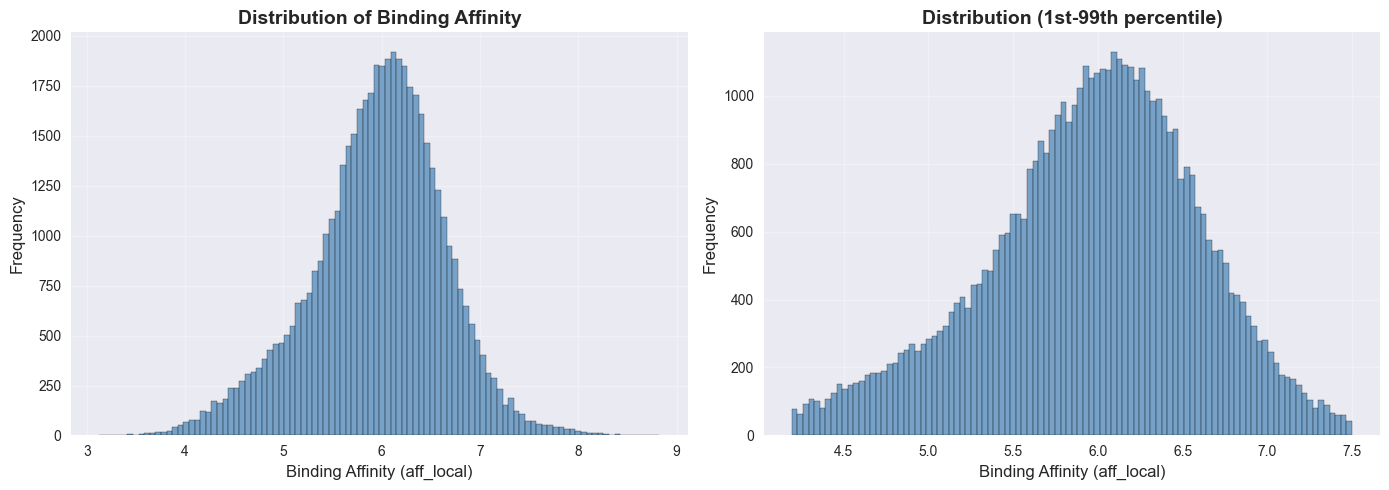

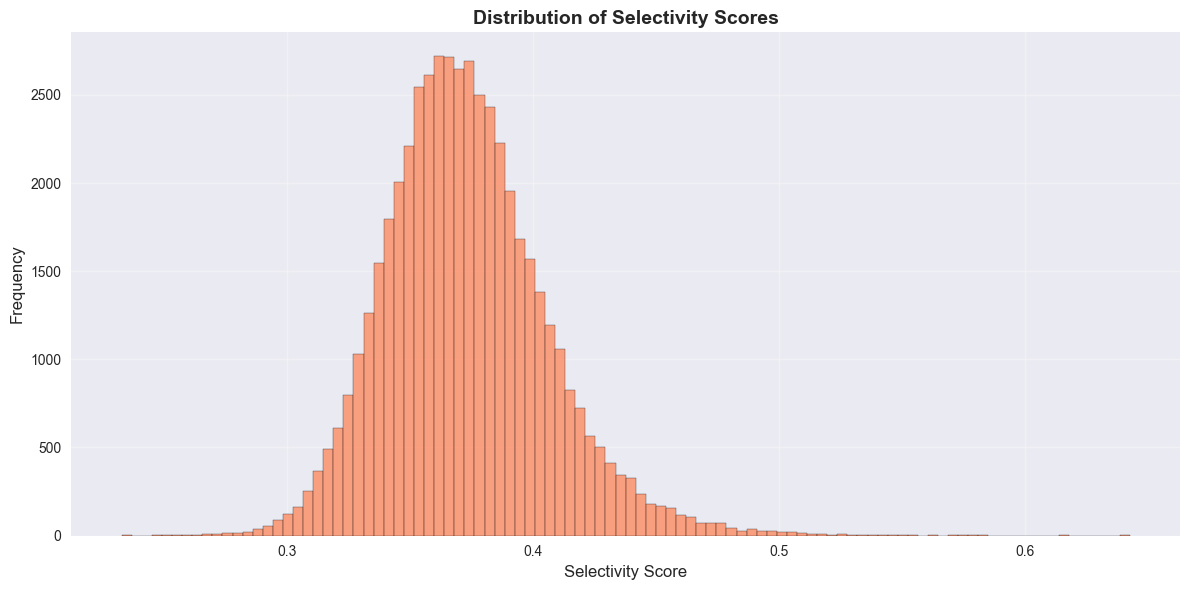

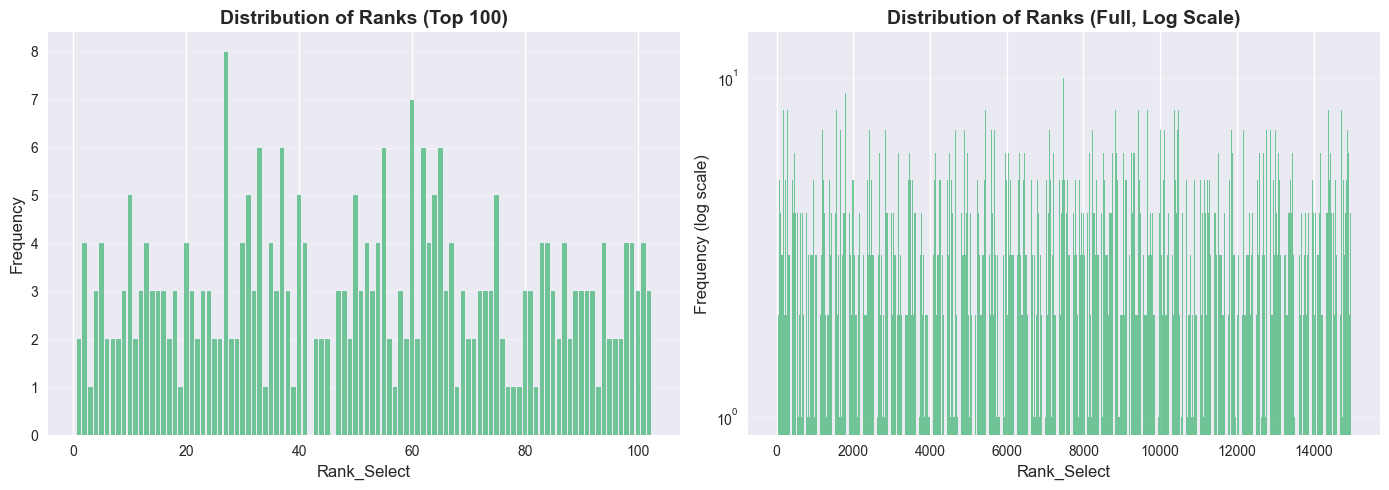

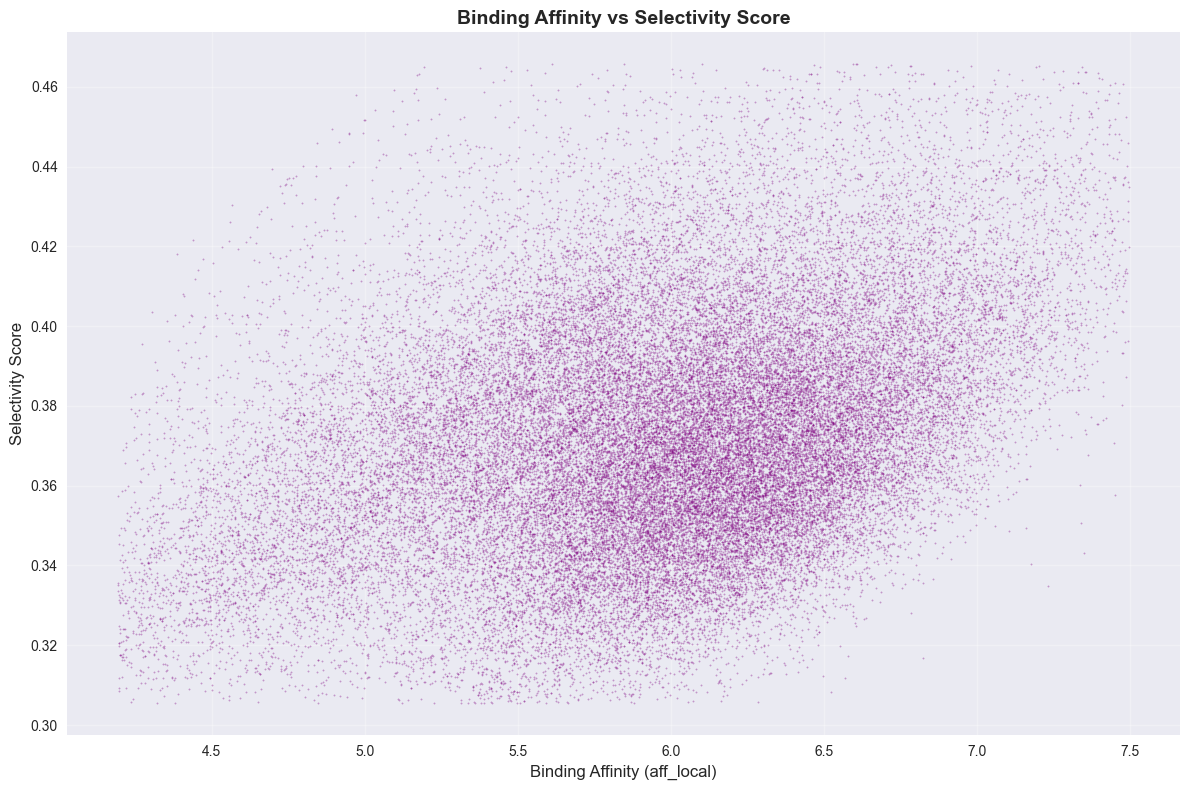

In [16]:
# Load sample data for visualization (memory-efficient)
print("Loading sample data for visualization (memory-efficient approach)...")
viz_sample_size = 50000
sample_dataframes = []

# Sample from multiple files
for parquet_file in parquet_file_paths[:20]:  # Sample from first 20 files
    try:
        df = pd.read_parquet(parquet_file)
        if len(df) > (viz_sample_size // 20):
            sample_df = df.sample(n=(viz_sample_size // 20), random_state=42)
        else:
            sample_df = df
        sample_dataframes.append(sample_df)
        del df
    except Exception as e:
        print(f"  Error loading {parquet_file.name}: {e}")

if sample_dataframes:
    viz_df = pd.concat(sample_dataframes, ignore_index=True)
    print(f"  Using sample of {len(viz_df):,} rows for visualization")
    
    if len(viz_df) > 0:
    
        # Distribution of binding affinity
        if 'aff_local' in viz_df.columns:
            plt.figure(figsize=(14, 5))
        
        plt.subplot(1, 2, 1)
        plt.hist(viz_df['aff_local'].dropna(), bins=100, edgecolor='black', alpha=0.7, color='steelblue')
        plt.xlabel('Binding Affinity (aff_local)', fontsize=12)
        plt.ylabel('Frequency', fontsize=12)
        plt.title('Distribution of Binding Affinity', fontsize=14, fontweight='bold')
        plt.grid(alpha=0.3)
        
        plt.subplot(1, 2, 2)
        # Remove extreme outliers for better visualization
        q1 = viz_df['aff_local'].quantile(0.01)
        q99 = viz_df['aff_local'].quantile(0.99)
        filtered_aff = viz_df[(viz_df['aff_local'] >= q1) & (viz_df['aff_local'] <= q99)]['aff_local']
        plt.hist(filtered_aff, bins=100, edgecolor='black', alpha=0.7, color='steelblue')
        plt.xlabel('Binding Affinity (aff_local)', fontsize=12)
        plt.ylabel('Frequency', fontsize=12)
        plt.title('Distribution (1st-99th percentile)', fontsize=14, fontweight='bold')
        plt.grid(alpha=0.3)
        
        plt.tight_layout()
        plt.show()
    
        # Distribution of selectivity score
        if 'Selectivity_Score' in viz_df.columns:
            plt.figure(figsize=(12, 6))
        plt.hist(viz_df['Selectivity_Score'].dropna(), bins=100, edgecolor='black', alpha=0.7, color='coral')
        plt.xlabel('Selectivity Score', fontsize=12)
        plt.ylabel('Frequency', fontsize=12)
        plt.title('Distribution of Selectivity Scores', fontsize=14, fontweight='bold')
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()
    
        # Distribution of rank
        if 'Rank_Select' in viz_df.columns:
            plt.figure(figsize=(14, 5))
        
        plt.subplot(1, 2, 1)
        # Show distribution of ranks (focus on lower ranks)
        rank_counts = viz_df['Rank_Select'].value_counts().sort_index().head(100)
        plt.bar(rank_counts.index, rank_counts.values, alpha=0.7, color='mediumseagreen')
        plt.xlabel('Rank_Select', fontsize=12)
        plt.ylabel('Frequency', fontsize=12)
        plt.title('Distribution of Ranks (Top 100)', fontsize=14, fontweight='bold')
        plt.grid(alpha=0.3, axis='y')
        
        plt.subplot(1, 2, 2)
        # Log scale for full distribution
        rank_counts_all = viz_df['Rank_Select'].value_counts().sort_index()
        plt.bar(rank_counts_all.index, rank_counts_all.values, alpha=0.7, color='mediumseagreen')
        plt.xlabel('Rank_Select', fontsize=12)
        plt.ylabel('Frequency (log scale)', fontsize=12)
        plt.title('Distribution of Ranks (Full, Log Scale)', fontsize=14, fontweight='bold')
        plt.yscale('log')
        plt.grid(alpha=0.3, axis='y')
        
        plt.tight_layout()
        plt.show()
    
        # Scatter plot: Binding Affinity vs Selectivity Score
        if 'aff_local' in viz_df.columns and 'Selectivity_Score' in viz_df.columns:
            plt.figure(figsize=(12, 8))
        
        # Remove outliers for better visualization
        q1_aff = viz_df['aff_local'].quantile(0.01)
        q99_aff = viz_df['aff_local'].quantile(0.99)
        q1_sel = viz_df['Selectivity_Score'].quantile(0.01)
        q99_sel = viz_df['Selectivity_Score'].quantile(0.99)
        
        filtered = viz_df[
            (viz_df['aff_local'] >= q1_aff) & (viz_df['aff_local'] <= q99_aff) &
            (viz_df['Selectivity_Score'] >= q1_sel) & (viz_df['Selectivity_Score'] <= q99_sel)
        ]
        
        plt.scatter(filtered['aff_local'], filtered['Selectivity_Score'], 
                   alpha=0.3, s=1, c='purple')
        plt.xlabel('Binding Affinity (aff_local)', fontsize=12)
        plt.ylabel('Selectivity Score', fontsize=12)
        plt.title('Binding Affinity vs Selectivity Score', fontsize=14, fontweight='bold')
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()

## 6. Drug Selectivity Analysis

Analyze drug selectivity patterns and classifications.

In [17]:
# Merge drug metrics with UMAP data for comprehensive analysis
if 'Drug' in drug_metrics_df.columns and 'Drug' in drug_umap_df.columns:
    drug_combined = drug_metrics_df.merge(
        drug_umap_df[['Drug', 'Type', 'cluster', 'x', 'y']],
        on='Drug',
        how='left'
    )
    
    print("=" * 80)
    print("DRUG SELECTIVITY BY TYPE")
    print("=" * 80)
    
    if 'Type' in drug_combined.columns and 'Selectivity_Score' in drug_combined.columns:
        type_stats = drug_combined.groupby('Type')['Selectivity_Score'].agg(['mean', 'median', 'std', 'count'])
        print("\nSelectivity Score by Drug Type:")
        display(type_stats)
        
        print("\nTop 10 most selective drugs (by type):")
        for drug_type in drug_combined['Type'].dropna().unique():
            type_drugs = drug_combined[drug_combined['Type'] == drug_type]
            top_selective = type_drugs.nlargest(10, 'Selectivity_Score')
            print(f"\n{drug_type}:")
            display_cols = ['Drug Name', 'Selectivity_Score', 'n_targets_measured', 'Clinical Trial Phase']
            available = [col for col in display_cols if col in top_selective.columns]
            display(top_selective[available])

DRUG SELECTIVITY BY TYPE

Selectivity Score by Drug Type:


,mean,median,std,count
Type,,,,
Type I: Highly Selective,0.181244,0.176415,0.033078,4106
Type II: Moderate poly-target,0.217403,0.210565,0.042676,2793
Type III: Broad-spectrum,0.119799,0.120648,0.028839,8082



Top 10 most selective drugs (by type):

Type II: Moderate poly-target:


,Drug Name,Selectivity_Score,n_targets_measured,Clinical Trial Phase
2756,Dasatinib,0.809570,20385,4.0
7994,Canertinib,0.472281,20385,3.0
679,Afatinib,0.429007,20385,4.0
9741,Pd-0173955,0.411061,20385,NaN
12751,Paroxetine,0.403255,20385,4.0
13896,Chembl565372,0.402176,20385,NaN
7131,Propranolol,0.387539,20385,4.0
14846,Chembl92731,0.372185,20385,NaN
7136,Chembl270193,0.361929,20385,NaN
7172,Chembl271941,0.357194,20385,NaN



Type III: Broad-spectrum:


,Drug Name,Selectivity_Score,n_targets_measured,Clinical Trial Phase
9497,Chembl377175,0.198664,20385,NaN
3065,Liothyronine,0.194634,20385,4.0
6578,Chembl2397138,0.191962,20385,NaN
11019,Chembl4296682,0.191213,20385,NaN
6273,Chembl2315928,0.190872,20385,NaN
4587,Xl-418,0.189679,20385,1.0
8023,Chembl322251,0.188721,20385,NaN
8160,Chembl3286734,0.188668,20385,NaN
13856,Wye-354,0.188611,20385,NaN
6744,Chembl2443026,0.188440,20385,NaN



Type I: Highly Selective:


,Drug Name,Selectivity_Score,n_targets_measured,Clinical Trial Phase
3169,Hexoprenaline,0.600598,20385,2.0
11540,Isoproterenol,0.379885,20385,4.0
5741,Pranlukast,0.345683,20385,4.0
14879,Gefitinib,0.344885,20385,4.0
13782,Erlotinib,0.330072,20385,4.0
24,Vatalanib,0.323124,20385,3.0
669,Prucalopride,0.314367,20385,4.0
5509,Selodenoson,0.304118,20385,2.0
5705,Deoxyuridine Monophosphate,0.303222,20385,NaN
4427,Chembl195660,0.300886,20385,NaN


## 7. Target Binding Affinity Analysis

Analyze target binding affinity (pKd) and drug hit statistics.

In [18]:
print("=" * 80)
print("TARGET BINDING AFFINITY ANALYSIS")
print("=" * 80)

# Top targets by binding affinity
if 'Avg_pKd' in target_stats_df.columns:
    print("\nTop 20 targets by average binding affinity (pKd):")
    top_affinity = target_stats_df.nlargest(20, 'Avg_pKd')
    display_cols = ['Target', 'Gene', 'Avg_pKd', 'Max_pKd', 'N_hit', 'Avg_Selectivity_Score', 'Role']
    available = [col for col in display_cols if col in top_affinity.columns]
    display(top_affinity[available])

# Top targets by number of drug hits
if 'N_hit' in target_stats_df.columns:
    print("\nTop 20 targets by number of drug hits:")
    top_hits = target_stats_df.nlargest(20, 'N_hit')
    display_cols = ['Target', 'Gene', 'N_hit', 'Avg_pKd', 'Max_pKd', 'TPI', 'Role']
    available = [col for col in display_cols if col in top_hits.columns]
    display(top_hits[available])

TARGET BINDING AFFINITY ANALYSIS

Top 20 targets by average binding affinity (pKd):


,Target,Gene,Avg_pKd,Max_pKd,N_hit,Avg_Selectivity_Score,Role
0,CCR4_HUMAN,CCR4,7.245421,9.554837,14228,0.471425,Oncogene
1,KIT_HUMAN,KIT,7.230410,9.618177,13658,0.469659,Oncogene
2,CLTR2_HUMAN,CYSLTR2,7.213534,9.404004,14212,0.468701,Oncogene
3,CCR7_HUMAN,CCR7,7.204928,9.488377,14150,0.467908,Oncogene
4,CXCR4_HUMAN,CXCR4,7.204446,9.595966,14297,0.468042,Oncogene
5,APJ_HUMAN,APLNR,7.153969,9.319393,13959,0.463346,Both
6,ACKR3_HUMAN,ACKR3,7.104656,9.534197,14139,0.459389,Both
7,ABL1_HUMAN,ABL1,7.076578,10.592403,12647,0.455933,Oncogene
8,P2RY8_HUMAN,P2RY8,7.054448,9.478442,13770,0.454778,Both
9,EGFR_HUMAN,EGFR,6.974541,9.755207,12449,0.447223,Oncogene



Top 20 targets by number of drug hits:


,Target,Gene,N_hit,Avg_pKd,Max_pKd,TPI,Role
15,H13_HUMAN,H1-3,14421,6.629678,7.807652,0.962619,TSG
30,H14_HUMAN,H1-4,14418,6.506312,7.700858,0.962419,Oncogene
31,H14_HUMAN,HIST1H1E,14418,6.506312,7.700858,0.962419,Both
42,H15_HUMAN,H1-5,14312,6.454773,7.654064,0.955343,TSG
4,CXCR4_HUMAN,CXCR4,14297,7.204446,9.595966,0.954342,Oncogene
0,CCR4_HUMAN,CCR4,14228,7.245421,9.554837,0.949736,Oncogene
2,CLTR2_HUMAN,CYSLTR2,14212,7.213534,9.404004,0.948668,Oncogene
3,CCR7_HUMAN,CCR7,14150,7.204928,9.488377,0.944530,Oncogene
6,ACKR3_HUMAN,ACKR3,14139,7.104656,9.534197,0.943795,Both
5,APJ_HUMAN,APLNR,13959,7.153969,9.319393,0.931780,Both


## 8. Visualization

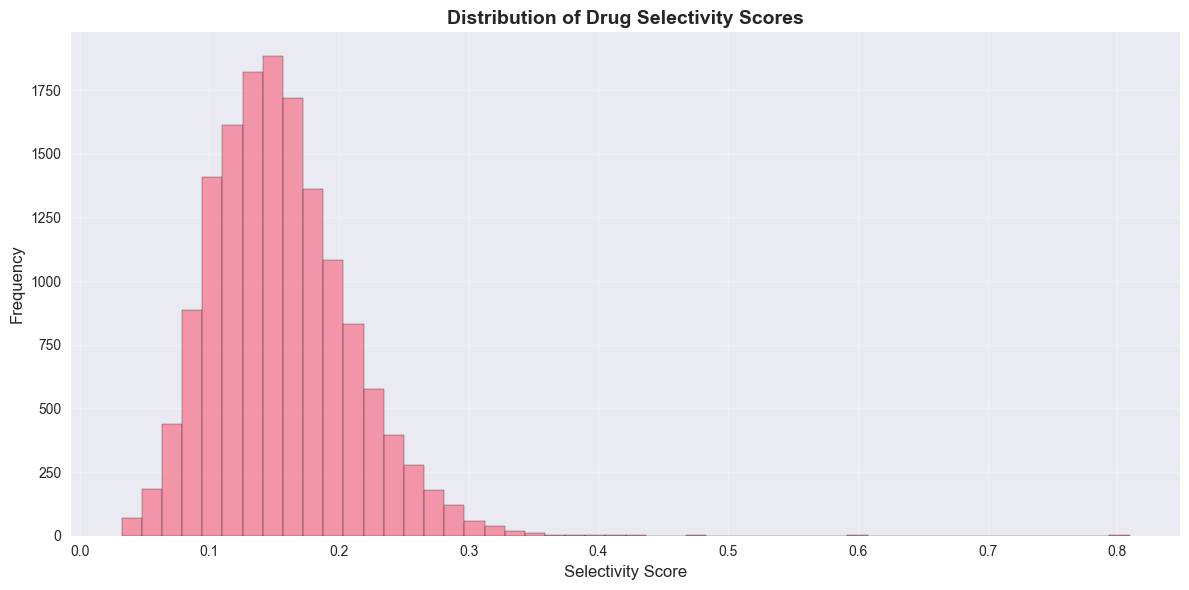

In [19]:
# Distribution of Selectivity Scores
if 'Selectivity_Score' in drug_metrics_df.columns:
    plt.figure(figsize=(12, 6))
    plt.hist(drug_metrics_df['Selectivity_Score'].dropna(), bins=50, edgecolor='black', alpha=0.7)
    plt.xlabel('Selectivity Score', fontsize=12)
    plt.ylabel('Frequency', fontsize=12)
    plt.title('Distribution of Drug Selectivity Scores', fontsize=14, fontweight='bold')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

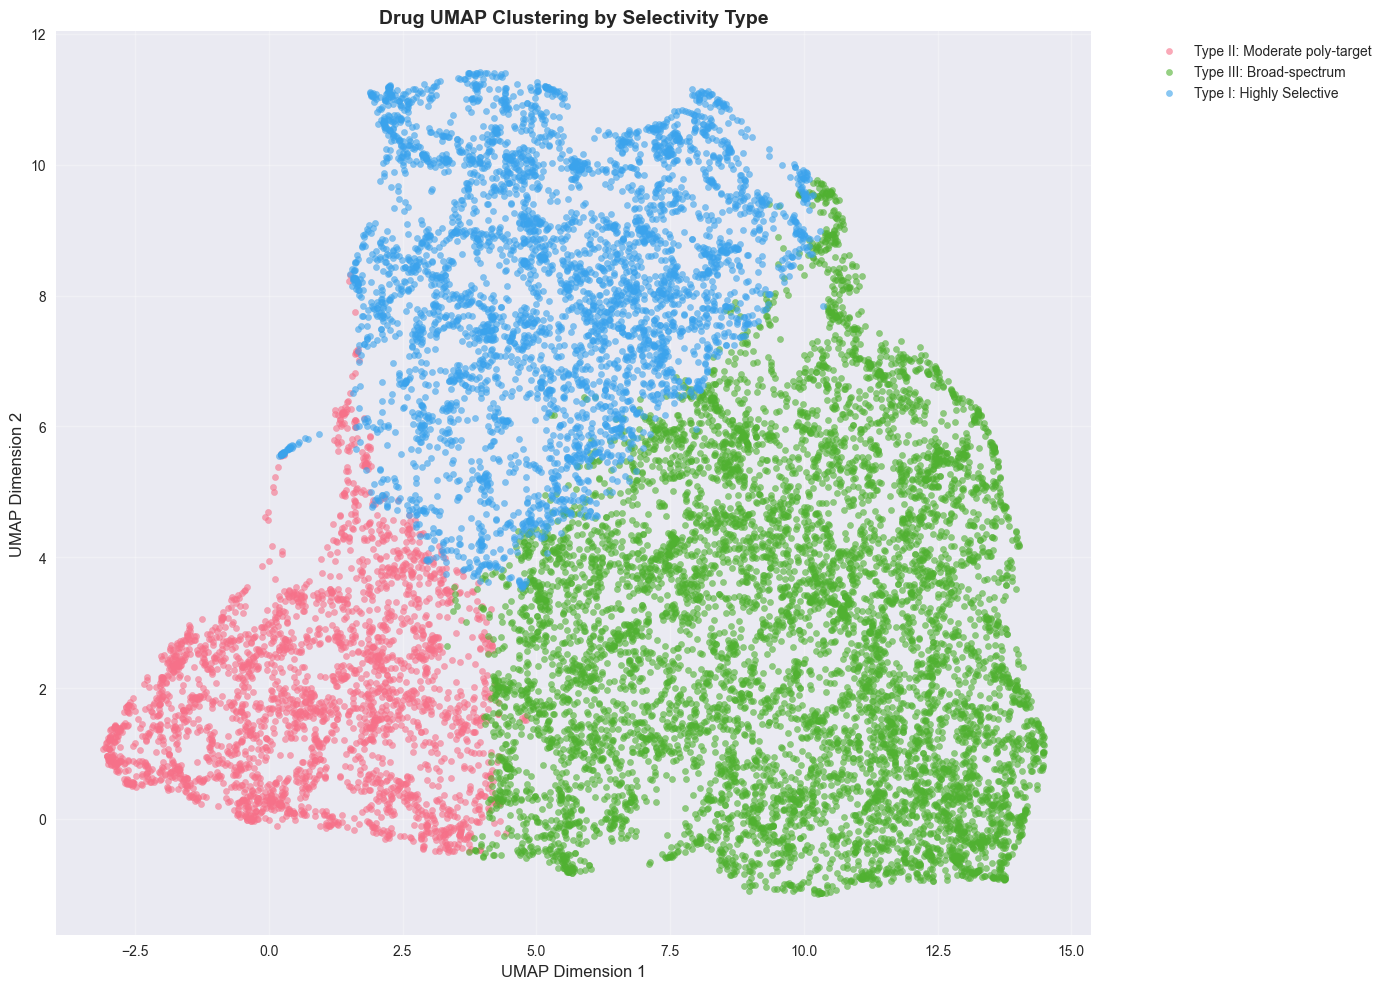

In [20]:
# UMAP visualization colored by drug type
if 'x' in drug_umap_df.columns and 'y' in drug_umap_df.columns and 'Type' in drug_umap_df.columns:
    plt.figure(figsize=(14, 10))
    
    # Plot each type with different color
    types = drug_umap_df['Type'].dropna().unique()
    colors = sns.color_palette("husl", len(types))
    
    for i, drug_type in enumerate(types):
        type_data = drug_umap_df[drug_umap_df['Type'] == drug_type]
        plt.scatter(type_data['x'], type_data['y'], 
                   label=drug_type, alpha=0.6, s=20, c=[colors[i]])
    
    plt.xlabel('UMAP Dimension 1', fontsize=12)
    plt.ylabel('UMAP Dimension 2', fontsize=12)
    plt.title('Drug UMAP Clustering by Selectivity Type', fontsize=14, fontweight='bold')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

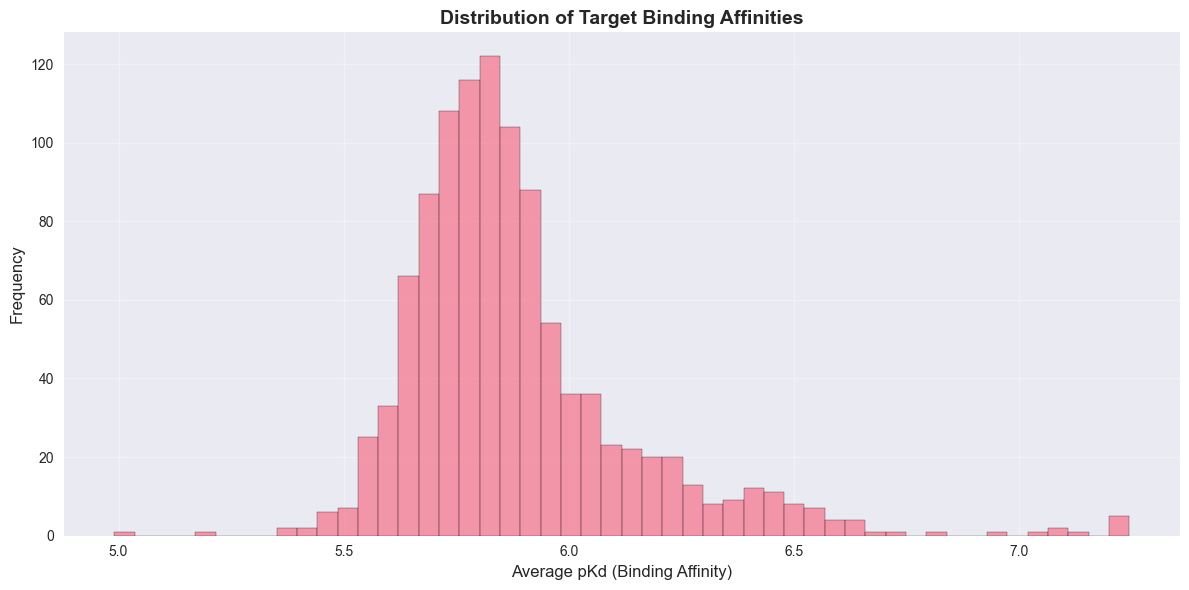

In [21]:
# Distribution of target binding affinities
if 'Avg_pKd' in target_stats_df.columns:
    plt.figure(figsize=(12, 6))
    plt.hist(target_stats_df['Avg_pKd'].dropna(), bins=50, edgecolor='black', alpha=0.7)
    plt.xlabel('Average pKd (Binding Affinity)', fontsize=12)
    plt.ylabel('Frequency', fontsize=12)
    plt.title('Distribution of Target Binding Affinities', fontsize=14, fontweight='bold')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

In [22]:
# Create drug ID to name mapping
def get_drug_name_mapping_from_metrics(df, drug_id_col='Drug Chembl ID', drug_name_col='Drug Name'):
    """Create mapping from drug ChEMBL ID to drug name."""
    if drug_id_col in df.columns and drug_name_col in df.columns:
        mapping = df[[drug_id_col, drug_name_col]].drop_duplicates()
        mapping = mapping[mapping[drug_id_col].notna() & mapping[drug_name_col].notna()]
        return dict(zip(mapping[drug_id_col], mapping[drug_name_col]))
    return {}

# Create target to gene mapping
def get_target_gene_mapping(df, target_col='Target', gene_col='Gene'):
    """Create mapping from target to gene symbol."""
    if target_col in df.columns and gene_col in df.columns:
        mapping = df[[target_col, gene_col]].drop_duplicates()
        mapping = mapping[mapping[target_col].notna() & mapping[gene_col].notna()]
        return dict(zip(mapping[target_col], mapping[gene_col]))
    return {}

# Create mappings
drug_id_to_name = get_drug_name_mapping_from_metrics(drug_metrics_df)
target_to_gene = get_target_gene_mapping(target_stats_df)

print(f"Drug ID to name mappings: {len(drug_id_to_name):,}")
print(f"Target to gene mappings: {len(target_to_gene):,}")

# Example lookups
example_drug_id = "CHEMBL1000"
example_target = "CCR4_HUMAN"

print(f"\nExample: Drug ID '{example_drug_id}' → Name: {drug_id_to_name.get(example_drug_id, 'Not found')}")
print(f"Example: Target '{example_target}' → Gene: {target_to_gene.get(example_target, 'Not found')}")

Drug ID to name mappings: 14,981
Target to gene mappings: 1,059

Example: Drug ID 'CHEMBL1000' → Name: Cetirizine
Example: Target 'CCR4_HUMAN' → Gene: CCR4


## 10. Integration Plan for explore_database.ipynb

### Proposed Integration Strategy

Based on the data exploration, here's how to integrate drug-target metrics into the main database system:

#### 1. **Data Loading Integration**
- Add drug-centric metrics loading to `database_query_module.py`
- Add target-centric statistics loading
- Optionally load parquet files on-demand (they're large and chunked)

#### 2. **New Query Functions**

**Drug Metrics Functions:**
- `get_drug_selectivity_info(drug_id/drug_name)`: Get selectivity scores and metrics
- `get_drugs_by_selectivity_type(type)`: Filter drugs by selectivity type
- `get_drugs_by_binding_affinity(min_pkd)`: Find drugs with strong binding

**Target Metrics Functions:**
- `get_target_binding_stats(gene/target)`: Get binding affinity statistics
- `get_targets_by_drug_hits(min_hits)`: Find targets with many drug hits
- `get_target_prioritization(gene)`: Get TPI and prioritization scores

**Combined Functions:**
- `get_drug_target_binding_affinity(drug_id, gene)`: Get specific drug-target binding data
- `get_targets_for_drug_with_affinity(drug_id)`: Get all targets with binding affinities for a drug

#### 3. **Evidence Integration**
- Use binding affinity (pKd) as evidence for drug-target associations
- Use selectivity scores to rank target importance
- Combine with existing EHR and drug response data for comprehensive evidence

#### 4. **Visualization Integration**
- Add UMAP visualization to show drug clustering
- Add binding affinity heatmaps
- Add selectivity score distributions

#### 5. **LLM Agent Enhancement**
- Add queries like "What is the binding affinity of drug X to target Y?"
- "Which targets have the highest binding affinity for drug X?"
- "What is the selectivity profile of drug X?"

### Key Integration Points

1. **Link to existing drug data**: Use ChEMBL IDs to link with `drug_target_disease` data
2. **Link to existing target data**: Use Gene symbols to link with `onco_genes` and target priority data
3. **Evidence hierarchy**: 
   - Binding affinity (pKd) → Direct binding evidence
   - Selectivity scores → Target importance
   - Combined with EHR and drug response → Comprehensive evidence

### File Organization

- Keep parquet files in `target_centric_pan/` folder (load on-demand)
- Rename CSV files to concise names:
  - `drug_centric_pan_uniprot.csv` → `drug_selectivity_metrics.csv`
  - `drug_centric_pan_uniprot_umap.csv` → `drug_umap_clustering.csv`
  - `target_stats_sorted_onco.csv` → `target_binding_stats.csv`
  - `drug_name_clin_phase.csv` → `drug_phase_mapping.csv` (or merge into main drug data)
